# 1. Business Understanding

Customer churn can negatively impact revenue and increase the cost of acquiring replacement customers. Identifying customers who are at risk of leaving can help businesses take proactive steps to improve retention.

The objective of this project is to analyze customer characteristics and behavioral patterns associated with churn and develop a machine learning model that can identify customers who are likely to churn.

Because the business goal is to identify as many at-risk customers as possible, **Recall** is used as the primary evaluation metric. A false negative represents a customer who actually churns but is predicted to remain, which could result in a missed opportunity for proactive retention.

The results of this analysis can help support targeted retention strategies by identifying important churn indicators and customers who may benefit from early intervention.

In [ ]:
# =============================================================================
# IMPORTS AND SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("="*70)
print("CUSTOMER CHURN PREDICTION - EXPLORATORY DATA ANALYSIS")
print("="*70)

CUSTOMER CHURN PREDICTION - EXPLORATORY DATA ANALYSIS


# 2. Load Dataset

The Customer Churn dataset is loaded into a pandas DataFrame for analysis.

In [3]:
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print(df.shape)

df.head()

(64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


# 3. Dataset Overview

This section explores the structure of the dataset, checks data types, identifies missing values, detects duplicate records, and summarizes the numerical variables before any preprocessing.

In [4]:
print("\n" + "="*60)
print("3. DATASET OVERVIEW")
print("="*60)

print("\nData Types")
display(df.dtypes)

print("\nDataset Information")
df.info()

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nDescriptive Statistics")
display(df.describe())


3. DATASET OVERVIEW

Data Types


CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB

Missing Values


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


Duplicate Records
0

Descriptive Statistics


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### Dataset Summary

The dataset contains **64,374 customer records** and **12 variables**, including demographic information, customer behavior, subscription details, and the target variable (`Churn`).

Key observations from the initial inspection include:

- The dataset contains **no missing values**, so no imputation is required.
- There are **no duplicate records**, indicating that each customer record is unique.
- Nine variables are numerical and three are categorical (`Gender`, `Subscription Type`, and `Contract Length`).
- The target variable (`Churn`) is binary, making this a **binary classification** problem.
- The dataset is clean and ready for exploratory data analysis and feature engineering.

# 4. Data Cleaning

Before performing exploratory data analysis and building machine learning models, the dataset was examined for common data quality issues such as missing values, duplicate records, incorrect data types, and unnecessary variables.

In [5]:
print("\n" + "="*60)
print("4. DATA CLEANING")
print("="*60)

# Create a copy of the original dataset
df_clean = df.copy()

# Drop CustomerID since it is only an identifier
df_clean.drop("CustomerID", axis=1, inplace=True)

print(f"Dataset Shape after removing CustomerID: {df_clean.shape}")

print("\nRemaining Columns:")
print(df_clean.columns.tolist())


4. DATA CLEANING
Dataset Shape after removing CustomerID: (64374, 11)

Remaining Columns:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


### Data Cleaning Summary

No missing values or duplicate records were found during the initial inspection, so no imputation or duplicate removal was required.

The `CustomerID` column was removed because it uniquely identifies each customer but does not provide predictive value for customer churn. Removing this identifier helps prevent the model from learning meaningless patterns.

# 5. Feature Engineering

Feature engineering was performed to create business-friendly categorical variables from continuous numerical features. These engineered features improve interpretability during exploratory data analysis and help identify customer segments associated with churn.

The original variables are retained for modeling, while the engineered variables are primarily used for visualization and business insights.

In [6]:
print("\n" + "="*60)
print("5. FEATURE ENGINEERING")
print("="*60)

# Create a copy
df_fe = df_clean.copy()

# -----------------------------
# Tenure Groups
# -----------------------------
df_fe["Tenure Group"] = pd.cut(
    df_fe["Tenure"],
    bins=[0,12,24,36,48,60],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-36 Months",
        "37-48 Months",
        "49-60 Months"
    ],
    include_lowest=True
)

# -----------------------------
# Payment Delay Groups
# -----------------------------
df_fe["Payment Delay Group"] = pd.cut(
    df_fe["Payment Delay"],
    bins=[-1,0,7,15,30],
    labels=[
        "No Delay",
        "1-7 Days",
        "8-15 Days",
        "16-30 Days"
    ]
)

# -----------------------------
# Support Calls Groups
# -----------------------------
df_fe["Support Call Group"] = pd.cut(
    df_fe["Support Calls"],
    bins=[-1,2,5,8,10],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

display(df_fe.head())


5. FEATURE ENGINEERING


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Tenure Group,Payment Delay Group,Support Call Group
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1,25-36 Months,16-30 Days,Moderate
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0,25-36 Months,8-15 Days,High
2,47,Male,27,10,2,29,Premium,Annual,757,21,0,25-36 Months,16-30 Days,Low
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,0-12 Months,16-30 Days,Moderate
4,53,Female,58,24,9,2,Standard,Annual,533,18,0,49-60 Months,1-7 Days,Very High


### Feature Engineering Summary

Three additional categorical features were created to improve the interpretability of the dataset:

- **Tenure Group** categorizes customers based on the length of their relationship with the company.
- **Payment Delay Group** groups customers according to the number of days payments were delayed.
- **Support Call Group** classifies customers by the frequency of customer support interactions.

These engineered features make it easier to analyze customer behavior and identify patterns related to customer churn during exploratory data analysis.

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the characteristics of the dataset, identify relationships between variables, detect potential patterns associated with customer churn, and generate business insights before developing predictive models.

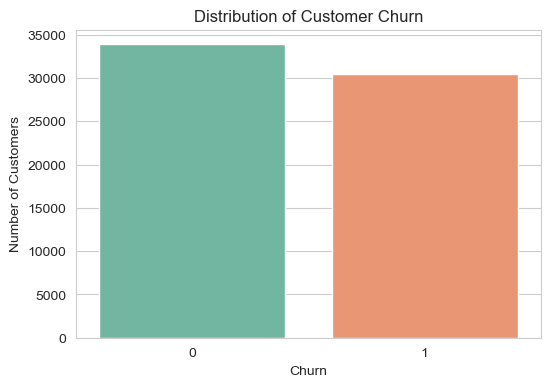

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_fe,
    x="Churn",
    palette="Set2"
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Key Findings

The target variable is relatively balanced, with slightly more customers remaining (`Churn = 0`) than leaving (`Churn = 1`). This indicates that the dataset does not suffer from severe class imbalance, making it suitable for training and evaluating classification models without requiring specialized resampling techniques.

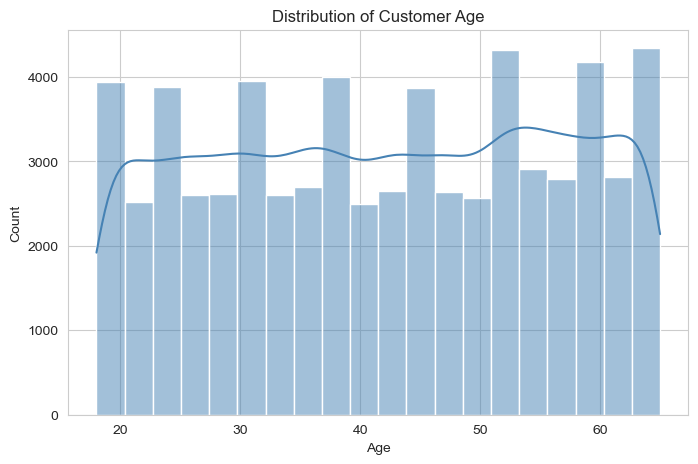

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_fe["Age"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")

plt.show()

### Key Findings

Customer ages range from approximately **18 to 65 years**, with observations distributed fairly evenly across the age groups. There is no strong age concentration, suggesting that the dataset represents customers from a broad range of adult age groups. Further analysis is required to determine whether age influences customer churn.

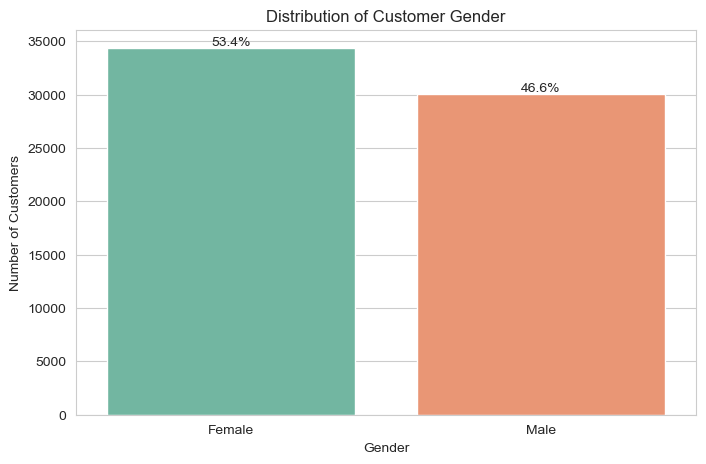

In [9]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_fe,
    x="Gender",
    palette="Set2"
)

total = len(df_fe)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center',
                va='bottom')

plt.title("Distribution of Customer Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Key Findings

The dataset contains **53.4% female customers** and **46.6% male customers**, indicating a relatively balanced gender distribution. Both genders are well represented, allowing meaningful comparisons during subsequent churn analysis without significant sampling bias.

## 6.4 Subscription Type Distribution

This visualization examines the distribution of customers across different subscription plans.

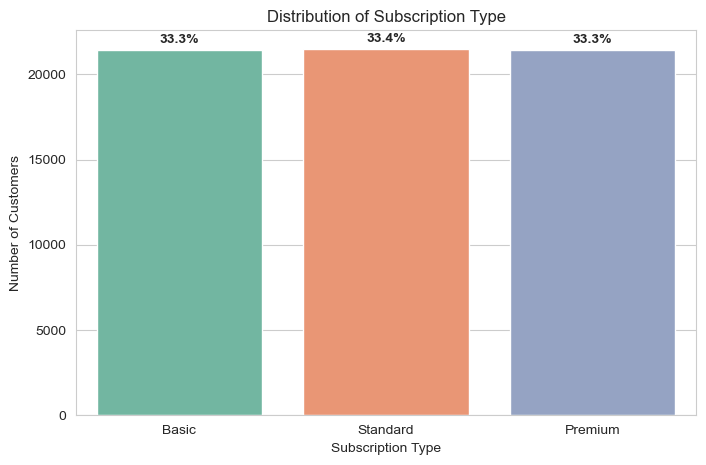

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_fe,
    x="Subscription Type",
    palette="Set2"
)

total = len(df_fe)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width()/2., p.get_height()),
        xytext=(0,5),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Distribution of Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")

plt.show()

### Key Findings

The three subscription plans are almost equally represented in the dataset, with each accounting for approximately one-third of all customers. This balanced distribution ensures that comparisons between subscription types are not biased by unequal sample sizes and provides a reliable basis for evaluating their relationship with customer churn.

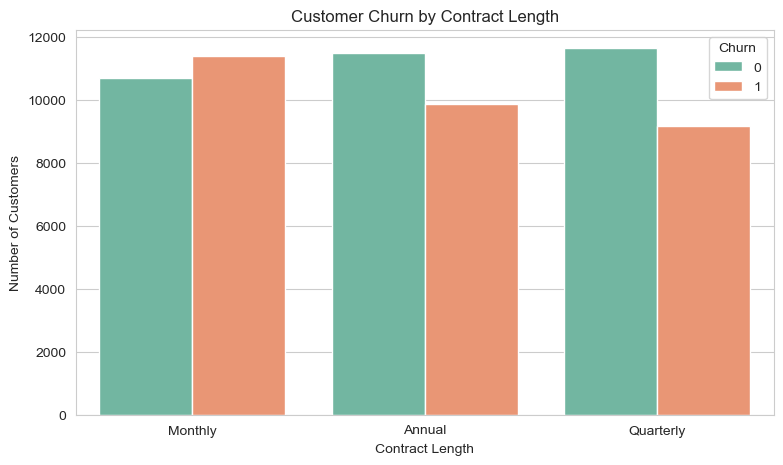

In [11]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df_fe,
    x="Contract Length",
    hue="Churn",
    palette="Set2"
)

plt.title("Customer Churn by Contract Length")
plt.xlabel("Contract Length")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

plt.show()

### Key Findings

Customer churn varies across contract lengths. Customers with **monthly contracts** exhibit the highest number of churned customers, with churn slightly exceeding the number of retained customers. In contrast, customers with **annual** and **quarterly contracts** show higher retention than churn, suggesting that longer-term contracts are associated with improved customer retention. This indicates that contract length may be an important predictor of customer churn.

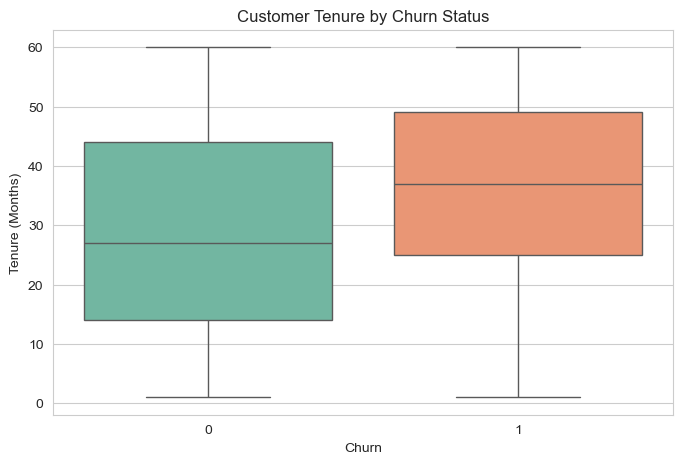

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fe,
    x="Churn",
    y="Tenure",
    palette="Set2"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Key Findings

Customers who churned (`Churn = 1`) generally have **higher tenure** than customers who remained (`Churn = 0`). The median tenure for churned customers is noticeably higher, although both groups have a wide range of customer lifetimes.

This indicates that, in this dataset, churn is **not limited to newer customers**. Instead, customers with longer relationships may also leave the service, suggesting that tenure alone is not sufficient to explain customer churn and should be evaluated together with other features.

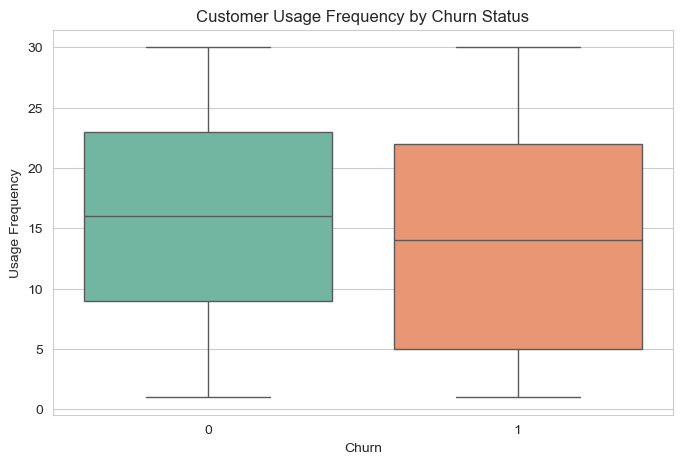

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fe,
    x="Churn",
    y="Usage Frequency",
    palette="Set2"
)

plt.title("Customer Usage Frequency by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Usage Frequency")

plt.show()

### Key Findings

Customers who remained (`Churn = 0`) show a **slightly higher median usage frequency** than customers who churned (`Churn = 1`). However, the distributions overlap considerably, indicating that usage frequency alone does not clearly distinguish churned from retained customers.

This suggests that while customer engagement may have some relationship with churn, it is likely **more informative when combined with other variables** such as contract length, payment behavior, or support interactions.

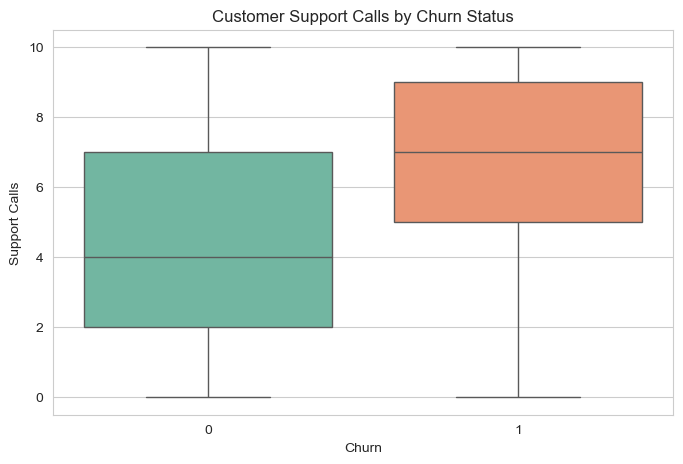

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fe,
    x="Churn",
    y="Support Calls",
    palette="Set2"
)

plt.title("Customer Support Calls by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Support Calls")

plt.show()

### Key Findings

Customers who churned (`Churn = 1`) generally made **more support calls** than customers who remained (`Churn = 0`). The median number of support calls is noticeably higher for churned customers, suggesting that customers experiencing more service issues or requiring frequent assistance are more likely to leave.

This indicates that **support call frequency is a potentially important predictor of customer churn** and may reflect underlying customer dissatisfaction or unresolved service problems.

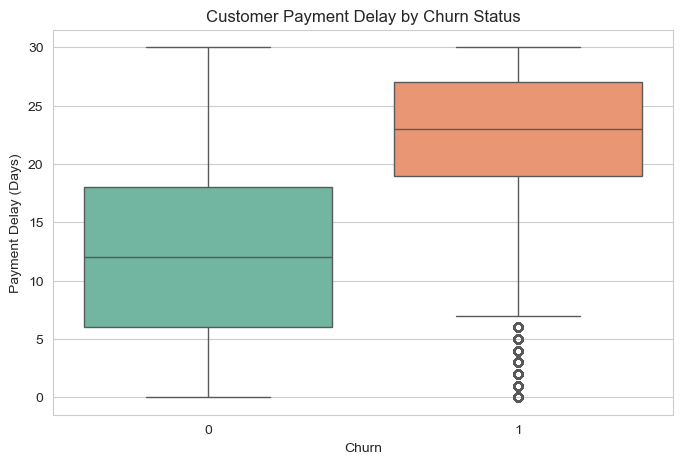

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fe,
    x="Churn",
    y="Payment Delay",
    palette="Set2"
)

plt.title("Customer Payment Delay by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Payment Delay (Days)")

plt.show()

### Key Findings

Customers who churned (`Churn = 1`) generally exhibit **longer payment delays** than customers who remained (`Churn = 0`). The median payment delay for churned customers is substantially higher, indicating that late payment behavior is associated with an increased likelihood of customer churn.

Although a few churned customers have short payment delays (shown as outliers), the overall distribution suggests that **payment delay is a strong predictor of customer churn** and may reflect declining customer commitment or financial difficulties.

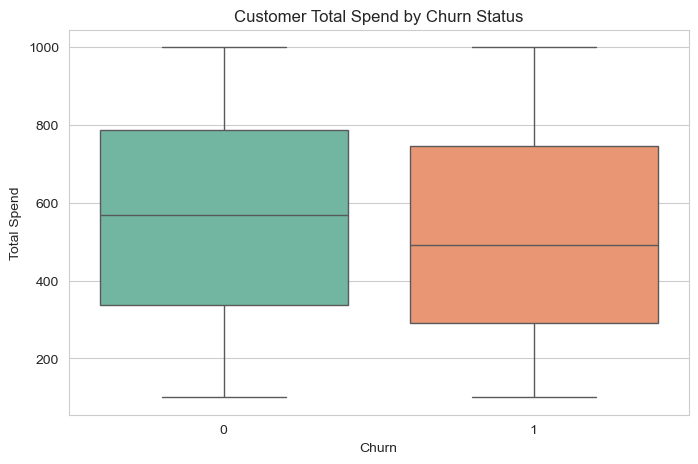

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fe,
    x="Churn",
    y="Total Spend",
    palette="Set2"
)

plt.title("Customer Total Spend by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Spend")

plt.show()

### Key Findings

Customers who remained (`Churn = 0`) exhibit a **slightly higher median total spend** than customers who churned (`Churn = 1`). However, the distributions overlap considerably, indicating that spending patterns alone do not clearly distinguish churned customers from retained customers.

This suggests that **total spend has limited predictive power on its own** and is likely to be more useful when analyzed alongside other features such as contract length, payment delay, and support calls.

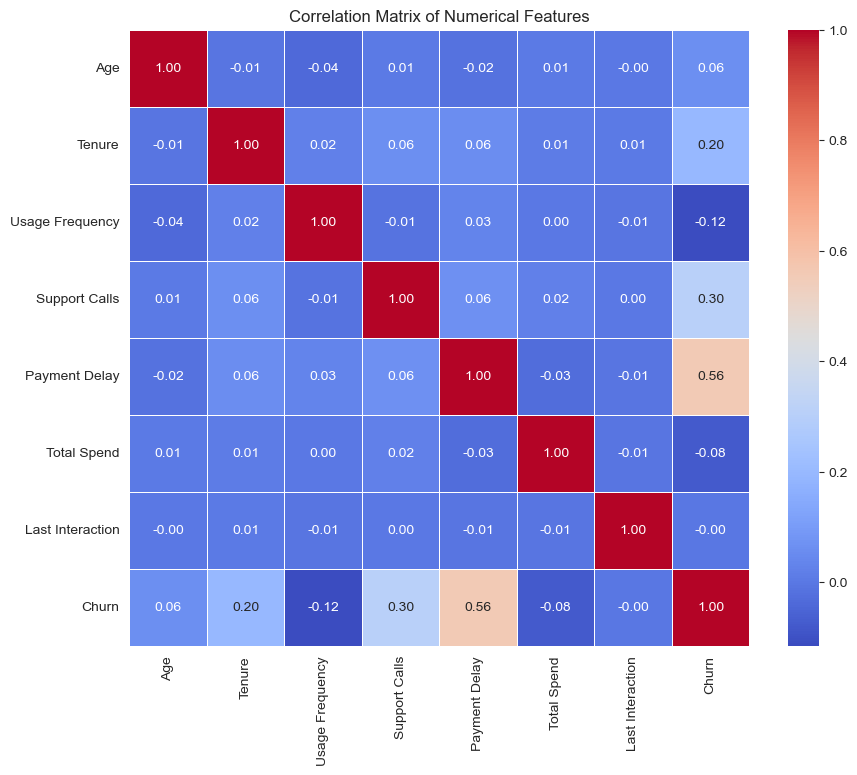

In [17]:
plt.figure(figsize=(10,8))

corr = df_fe.select_dtypes(include=["number"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

### Key Findings

The correlation matrix indicates that **Payment Delay** has the strongest positive relationship with customer churn (**correlation = 0.56**), suggesting that customers with longer payment delays are more likely to churn.

**Support Calls** (**0.30**) and **Tenure** (**0.20**) also show positive associations with churn, although their relationships are comparatively weaker. **Usage Frequency** has a weak negative correlation with churn (**-0.12**), indicating that customers who use the service more frequently tend to churn slightly less. **Age**, **Total Spend**, and **Last Interaction** exhibit little to no linear relationship with churn.

The predictor variables show **very low correlations with one another**, indicating minimal multicollinearity. This suggests that the numerical features contribute complementary information and can be used together when building predictive models.

# 7. Data Preprocessing

Before building the machine learning models, the dataset is prepared by separating the predictor variables from the target variable, identifying numerical and categorical features, and splitting the data into training and testing sets.

Categorical variables will be one-hot encoded, while numerical variables will be standardized. The preprocessing steps will be applied through a Scikit-learn pipeline so that transformations are learned only from the training data and data leakage is avoided.

In [18]:
# =============================================================================
# 7. DATA PREPROCESSING
# =============================================================================

print("\n" + "=" * 60)
print("7. DATA PREPROCESSING")
print("=" * 60)

# Use the cleaned dataset for modeling
model_df = df_clean.copy()

# Separate predictors and target
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print(f"\nPredictor shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nTarget Distribution:")
print(y.value_counts())

print("\nTarget Distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))


7. DATA PREPROCESSING

Predictor shape: (64374, 10)
Target shape: (64374,)

Target Distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

Target Distribution (%):
Churn
0    52.63
1    47.37
Name: proportion, dtype: float64


In [19]:
# Identify categorical and numerical features

categorical_features = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

print("Categorical Features:")
for feature in categorical_features:
    print(f"- {feature}")

print("\nNumerical Features:")
for feature in numerical_features:
    print(f"- {feature}")

Categorical Features:
- Gender
- Subscription Type
- Contract Length

Numerical Features:
- Age
- Tenure
- Usage Frequency
- Support Calls
- Payment Delay
- Total Spend
- Last Interaction


In [20]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Features: {X_train.shape}")
print(f"Testing Features:  {X_test.shape}")

print(f"\nTraining Target: {y_train.shape}")
print(f"Testing Target:  {y_test.shape}")

print("\nTraining Target Distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Target Distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Features: (51499, 10)
Testing Features:  (12875, 10)

Training Target: (51499,)
Testing Target:  (12875,)

Training Target Distribution (%):
Churn
0    52.63
1    47.37
Name: proportion, dtype: float64

Testing Target Distribution (%):
Churn
0    52.63
1    47.37
Name: proportion, dtype: float64


In [21]:
# Create preprocessing steps for numerical and categorical features

numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("\nNumerical features will be standardized using StandardScaler.")
print("Categorical features will be transformed using OneHotEncoder.")

Preprocessing pipeline created successfully.

Numerical features will be standardized using StandardScaler.
Categorical features will be transformed using OneHotEncoder.


### Preprocessing Summary

The target variable (`Churn`) was separated from the predictor variables, and the dataset was divided into **80% training data and 20% testing data** using stratified sampling to preserve the original churn distribution.

The numerical features will be standardized using `StandardScaler`, while the categorical variables (`Gender`, `Subscription Type`, and `Contract Length`) will be converted into numerical representations using one-hot encoding.

These preprocessing steps will be incorporated directly into the machine learning pipelines so that transformations are learned only from the training data, helping prevent data leakage.

# 8. Baseline Logistic Regression Model

Logistic Regression is used as the baseline classification model because customer churn is a binary classification problem. The model provides an interpretable benchmark that can later be compared with more complex machine learning models.

The model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and a Confusion Matrix. Recall is particularly important for this business problem because identifying customers who are likely to churn gives the company an opportunity to intervene with retention strategies.

In [22]:
# =============================================================================
# 8. BASELINE LOGISTIC REGRESSION MODEL
# =============================================================================

print("\n" + "=" * 60)
print("8. BASELINE LOGISTIC REGRESSION MODEL")
print("=" * 60)

# Create a pipeline that combines preprocessing and Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model
logistic_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred_lr = logistic_pipeline.predict(X_test)

# Generate probabilities for the positive churn class
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

print("\nLogistic Regression model trained successfully.")


8. BASELINE LOGISTIC REGRESSION MODEL

Logistic Regression model trained successfully.


### 8.1 Logistic Regression Model Evaluation

The baseline Logistic Regression model is evaluated on the held-out test set using multiple classification metrics. Because the goal of this project is to identify customers who are likely to churn, **Recall** is particularly important, as it measures how many actual churners the model successfully identifies.

Accuracy, Precision, F1-score, ROC-AUC, and the Confusion Matrix are also evaluated to provide a complete assessment of model performance.

In [23]:
# Evaluate the baseline Logistic Regression model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Baseline Logistic Regression Performance")
print("-" * 45)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Baseline Logistic Regression Performance
---------------------------------------------
Accuracy:  0.8270
Precision: 0.8137
Recall:    0.8234
F1-score:  0.8185
ROC-AUC:   0.9030

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



### Key Findings – Baseline Logistic Regression

The baseline Logistic Regression model achieved an **accuracy of 82.7%**, indicating that the model correctly classified a large majority of customers in the test set.

The model achieved a **recall of 82.3% for churned customers**, meaning that it successfully identified approximately 82% of customers who actually churned. This is particularly important for the business objective because identifying customers at risk of leaving provides an opportunity for proactive retention efforts.

The model also achieved a **precision of 81.4%** and an **F1-score of 81.9%**, showing a good balance between identifying churners and limiting false churn predictions.

The **ROC-AUC score of 0.903** indicates strong ability to distinguish between customers who churn and those who remain.

Overall, Logistic Regression provides a strong baseline model. Additional classification models will be evaluated to determine whether predictive performance can be improved.

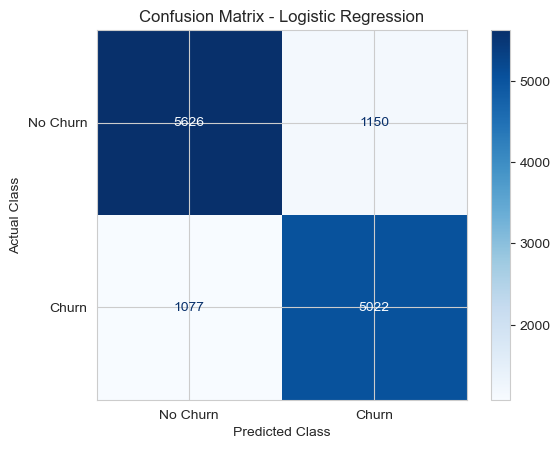

In [24]:
# Create confusion matrix for Logistic Regression

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides additional insight into the Logistic Regression model's predictions. The model correctly identified **5,626 non-churned customers** and **5,022 churned customers**.

It incorrectly classified **1,150 non-churned customers as churners (false positives)** and missed **1,077 customers who actually churned (false negatives)**.

From a customer retention perspective, false negatives are particularly important because these customers are at risk of churn but would not be identified for proactive retention efforts. Therefore, **Recall remains an important evaluation metric** when comparing models.

## 9. Decision Tree Model

A Decision Tree classifier is evaluated as an alternative to Logistic Regression. Unlike Logistic Regression, Decision Trees can capture nonlinear relationships and interactions between customer characteristics without assuming a linear relationship between predictors and churn.

The model will be evaluated using the same metrics as the baseline model so that its performance can be directly compared with Logistic Regression.

In [25]:
# Build and train Decision Tree model

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred_dt = decision_tree_pipeline.predict(X_test)

# Generate probabilities for ROC-AUC
y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### 9.1 Decision Tree Model Evaluation

The Decision Tree model is evaluated using the same performance metrics as the baseline Logistic Regression model: Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Using consistent evaluation metrics allows the models to be directly compared, with particular attention given to Recall because identifying customers who are likely to churn is important for proactive retention efforts.

In [26]:
# Evaluate Decision Tree model

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("-" * 40)
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-score:  {dt_f1:.4f}")
print(f"ROC-AUC:   {dt_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance
----------------------------------------
Accuracy:  0.9989
Precision: 0.9982
Recall:    0.9995
F1-score:  0.9989
ROC-AUC:   0.9989

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [27]:
# Check Decision Tree training vs. testing performance

y_pred_dt_train = decision_tree_pipeline.predict(X_train)

train_accuracy_dt = accuracy_score(y_train, y_pred_dt_train)
test_accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree - Overfitting Check")
print("-" * 40)
print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Testing Accuracy:  {test_accuracy_dt:.4f}")
print(f"Difference:        {train_accuracy_dt - test_accuracy_dt:.4f}")

Decision Tree - Overfitting Check
----------------------------------------
Training Accuracy: 1.0000
Testing Accuracy:  0.9989
Difference:        0.0011


### 9.2 Decision Tree Cross-Validation

To further evaluate whether the Decision Tree generalizes well to unseen data, 5-fold cross-validation is performed on the training dataset. Cross-validation evaluates the model across multiple subsets of the data rather than relying on a single train-test split.

Recall is used as the primary cross-validation metric because correctly identifying customers who are likely to churn is especially important for proactive customer retention efforts.

In [28]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation using recall
dt_cv_scores = cross_val_score(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("Decision Tree - 5-Fold Cross-Validation")
print("-" * 45)

print("Recall scores for each fold:")
print(dt_cv_scores)

print(f"\nMean CV Recall: {dt_cv_scores.mean():.4f}")
print(f"Standard Deviation: {dt_cv_scores.std():.4f}")

Decision Tree - 5-Fold Cross-Validation
---------------------------------------------
Recall scores for each fold:
[0.99815536 0.99856528 0.99713056 0.99754048 0.99815498]

Mean CV Recall: 0.9979
Standard Deviation: 0.0005


#### Cross-Validation Interpretation

The Decision Tree achieved a mean 5-fold cross-validation recall of **0.9979 (99.79%)**, with a very low standard deviation of **0.0005**. This indicates that the model performs consistently across different subsets of the training data.

The cross-validation results are also consistent with the model's strong performance on the held-out test set. Although the Decision Tree shows excellent predictive performance, additional models will be evaluated to determine whether similar performance can be achieved using alternative modeling approaches.

## 10. Random Forest Model

A Random Forest classifier is evaluated as an ensemble-based alternative to Logistic Regression and the Decision Tree. Random Forest combines predictions from multiple decision trees, which can improve predictive performance and reduce the risk of overfitting associated with a single Decision Tree.

The model is evaluated using the same metrics as the previous models: Accuracy, Precision, Recall, F1-score, and ROC-AUC. Recall remains particularly important because identifying customers who are likely to churn provides an opportunity for proactive retention efforts.

In [29]:
# Build and train Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred_rf = random_forest_pipeline.predict(X_test)

# Generate probabilities for ROC-AUC
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 10.1 Random Forest Model Evaluation

The Random Forest model is evaluated using the same performance metrics as Logistic Regression and the Decision Tree to allow for a consistent comparison across models.

In [30]:
# Evaluate Random Forest model

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-" * 40)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
----------------------------------------
Accuracy:  0.9988
Precision: 0.9997
Recall:    0.9977
F1-score:  0.9987
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



#### Key Findings – Random Forest

The Random Forest model demonstrated excellent predictive performance, achieving an **accuracy of 99.88%**, **precision of 99.97%**, **recall of 99.77%**, and an **F1-score of 99.87%**. The model also achieved a **ROC-AUC score of 1.000**, indicating excellent ability to distinguish between customers who churn and those who remain.

Compared with the baseline Logistic Regression model, Random Forest provides a substantial improvement across the evaluation metrics. Its performance is also comparable to the Decision Tree model.

Because identifying customers who are likely to churn is particularly important for proactive retention efforts, Recall remains a key metric when comparing the models.

The unusually high performance of both tree-based models will be further evaluated through cross-validation and model tuning before selecting a final model.

### 10.2 Random Forest Cross-Validation

To evaluate the stability and generalizability of the Random Forest model, 5-fold cross-validation is performed on the training dataset using Recall as the primary scoring metric.

This provides a more reliable estimate of model performance across different subsets of the data and allows for a consistent comparison with the Decision Tree model.

In [31]:
# Perform 5-fold cross-validation for Random Forest using Recall

rf_cv_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

print("Random Forest - 5-Fold Cross-Validation")
print("-" * 45)

print("Recall scores for each fold:")
print(rf_cv_scores)

print(f"\nMean CV Recall: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {rf_cv_scores.std():.4f}")

Random Forest - 5-Fold Cross-Validation
---------------------------------------------
Recall scores for each fold:
[0.99631072 0.9969256  0.99528592 0.99651568 0.99856499]

Mean CV Recall: 0.9967
Standard Deviation: 0.0011


#### Cross-Validation Interpretation

The Random Forest achieved a mean 5-fold cross-validation recall of **0.9967 (99.67%)**, with a low standard deviation of **0.0011**. This indicates that the model performs consistently across different subsets of the training data.

The cross-validation results are consistent with the strong performance observed on the held-out test set, providing additional evidence that the Random Forest generalizes well to unseen data.

Both the Decision Tree and Random Forest demonstrate very strong and stable performance. Hyperparameter tuning will next be performed to further evaluate and optimize model performance.

## 11. Hyperparameter Tuning

Hyperparameter tuning is performed using `GridSearchCV` to identify a combination of model parameters that provides strong predictive performance while controlling model complexity.

The Decision Tree is tuned first because it demonstrated the highest Recall among the evaluated models. Recall is used as the scoring metric because identifying customers who are likely to churn is particularly important for proactive customer retention efforts.

In [32]:
from sklearn.model_selection import GridSearchCV

# Define Decision Tree parameter grid
dt_param_grid = {
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

# Create GridSearchCV
dt_grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=dt_param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV on training data
dt_grid_search.fit(X_train, y_train)

print("Decision Tree Grid Search Complete")
print("-" * 45)

print("Best Parameters:")
print(dt_grid_search.best_params_)

print(f"\nBest Cross-Validation Recall: {dt_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Decision Tree Grid Search Complete
---------------------------------------------
Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}

Best Cross-Validation Recall: 0.9984


### 11.1 Tuned Decision Tree Evaluation

The best Decision Tree model identified through GridSearchCV is evaluated on the held-out test set. Its performance is compared with the original Decision Tree to determine whether hyperparameter tuning improves model performance while controlling model complexity.

In [33]:
# Retrieve the best Decision Tree model from GridSearchCV
best_dt_model = dt_grid_search.best_estimator_

# Generate predictions on the test set
y_pred_dt_tuned = best_dt_model.predict(X_test)

# Generate probabilities for ROC-AUC
y_prob_dt_tuned = best_dt_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
tuned_dt_accuracy = accuracy_score(y_test, y_pred_dt_tuned)
tuned_dt_precision = precision_score(y_test, y_pred_dt_tuned)
tuned_dt_recall = recall_score(y_test, y_pred_dt_tuned)
tuned_dt_f1 = f1_score(y_test, y_pred_dt_tuned)
tuned_dt_roc_auc = roc_auc_score(y_test, y_prob_dt_tuned)

print("Tuned Decision Tree Performance")
print("-" * 45)
print(f"Accuracy:  {tuned_dt_accuracy:.4f}")
print(f"Precision: {tuned_dt_precision:.4f}")
print(f"Recall:    {tuned_dt_recall:.4f}")
print(f"F1-score:  {tuned_dt_f1:.4f}")
print(f"ROC-AUC:   {tuned_dt_roc_auc:.4f}")

print("\nBest Parameters:")
print(dt_grid_search.best_params_)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_tuned))

Tuned Decision Tree Performance
---------------------------------------------
Accuracy:  0.9984
Precision: 0.9971
Recall:    0.9995
F1-score:  0.9983
ROC-AUC:   0.9993

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



### Tuned Decision Tree Findings

Hyperparameter tuning produced a Decision Tree with very strong predictive performance. The tuned model achieved an accuracy of **99.84%**, precision of **99.71%**, recall of **99.95%**, F1-score of **99.83%**, and ROC-AUC of **99.93%**.

Recall is the primary evaluation metric for this project because failing to identify a customer who is likely to churn could result in a missed opportunity for proactive retention. The tuned Decision Tree identified nearly all customers who actually churned.

The tuned model also maintains a strong balance between precision and recall, as reflected by its F1-score of 99.83%. Overall, the results indicate that the Decision Tree is highly effective at distinguishing between customers who churn and those who remain.

Because the model performance is unusually high, the results should be interpreted carefully. Additional model comparison and feature analysis will be used to better understand the predictive patterns in the dataset.

## 12. Model Comparison

The classification models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Recall is emphasized because identifying customers who are likely to churn is especially important for proactive customer retention.

The comparison includes the baseline Logistic Regression model, Decision Tree, Random Forest, and Tuned Decision Tree.

In [34]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        0.9984
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        0.9971
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        0.9995
    ],
    "F1-Score": [
        f1,
        dt_f1,
        rf_f1,
        0.9983
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        0.9993
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8270,0.8137,0.8234,0.8185,0.9030
1,Decision Tree,0.9989,0.9982,0.9995,0.9989,0.9989
2,Random Forest,0.9988,0.9997,0.9977,0.9987,1.0000
3,Tuned Decision Tree,0.9984,0.9971,0.9995,0.9983,0.9993


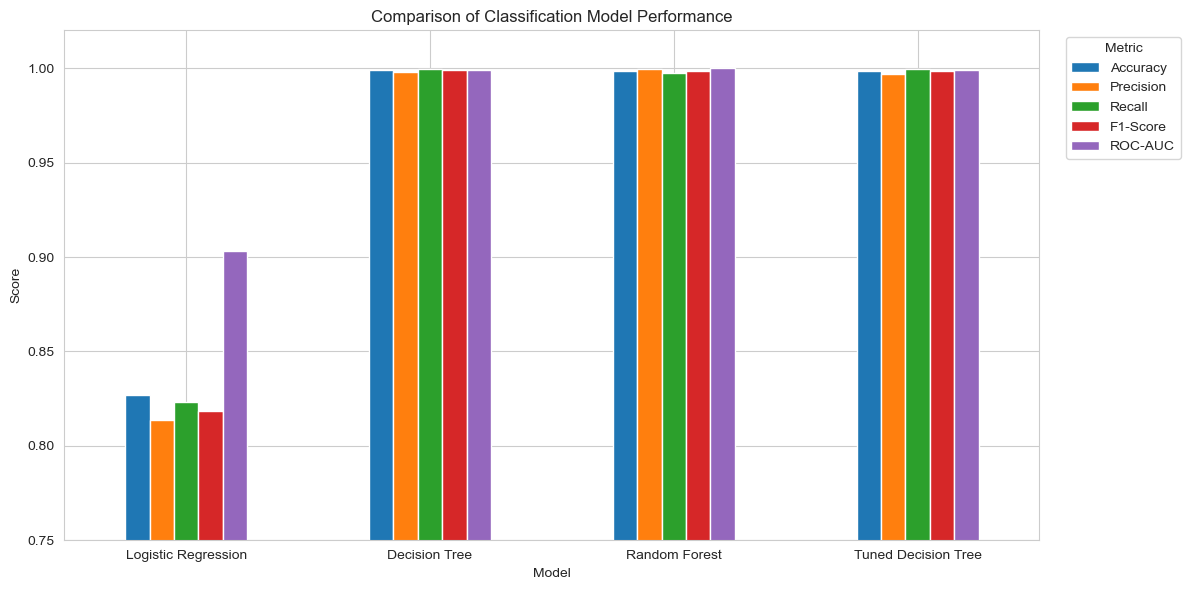

In [35]:
# Visualize model performance comparison

comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Classification Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.75, 1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Model Comparison Findings

The tree-based models substantially outperformed the baseline Logistic Regression model across all evaluation metrics.

Logistic Regression achieved a recall of **82.34%**, while the Decision Tree achieved **99.95%**, the Random Forest achieved **99.77%**, and the Tuned Decision Tree achieved **99.95%**.

Because recall is the primary evaluation metric for this project, both the Decision Tree and Tuned Decision Tree performed especially well at identifying customers who actually churned. The Decision Tree also achieved the highest F1-score (**99.89%**) among the evaluated models, while Random Forest achieved the highest precision (**99.97%**) and ROC-AUC (**1.0000**).

Hyperparameter tuning did not improve the Decision Tree's test-set performance compared with the original Decision Tree. However, the tuned model still demonstrated extremely strong predictive performance.

Overall, the results suggest that nonlinear relationships in the customer data are highly predictive of churn. However, because the tree-based models achieved unusually high performance, these results should be interpreted cautiously and the underlying predictive features should be examined before drawing final business conclusions.

## 13. Feature Importance

To better understand the factors driving customer churn predictions, feature importance is examined using the Random Forest model.

Feature importance measures how much each predictor contributes to the model's decisions. This analysis helps translate the predictive model into business insights by identifying the customer characteristics and behaviors that have the greatest influence on churn predictions.

In [36]:
# Extract feature importance from the Random Forest model

# Get feature names after preprocessing
feature_names = random_forest_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance values
rf_model = random_forest_pipeline.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,num__Payment Delay,0.436458
3,num__Support Calls,0.164524
1,num__Tenure,0.115217
2,num__Usage Frequency,0.083847
5,num__Total Spend,0.051814
0,num__Age,0.040740
8,cat__Gender_Male,0.031256
7,cat__Gender_Female,0.028301
13,cat__Contract Length_Monthly,0.013586
6,num__Last Interaction,0.013286


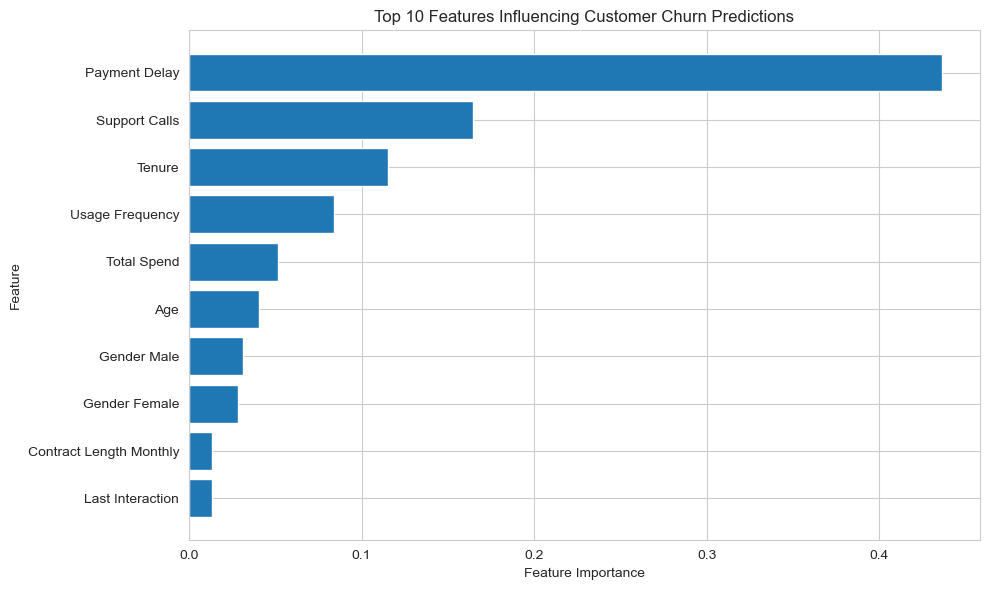

In [37]:
# Create cleaner feature names for visualization

feature_importance_plot = feature_importance.head(10).copy()

feature_importance_plot["Feature"] = (
    feature_importance_plot["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Customer Churn Predictions")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance Findings

The Random Forest feature importance analysis indicates that **Payment Delay** is the strongest predictor of customer churn, accounting for approximately **43.6%** of the model's total feature importance.

**Support Calls** is the second most influential feature at approximately **16.5%**, followed by **Tenure** at **11.5%** and **Usage Frequency** at **8.4%**. Total Spend and Age also contribute to the model's predictions, although to a lesser extent.

These findings are consistent with the exploratory data analysis, where Payment Delay showed the strongest positive relationship with churn. Together, the results suggest that payment behavior and customer support interactions are particularly important signals for identifying customers who may be at risk of leaving.

From a business perspective, customers experiencing repeated payment delays or frequent support interactions may represent important groups for proactive retention efforts. These customers could potentially benefit from targeted outreach, payment assistance, improved customer support, or personalized retention offers.

Feature importance indicates how strongly a variable contributes to the model's predictions, but it does not by itself establish that the variable causes customer churn.

## 14. Final Model Selection

Based on the model comparison, the **Decision Tree** was selected as the final model for this customer churn analysis.

The primary evaluation metric for this project is **Recall**, because failing to identify a customer who is likely to churn may result in a missed opportunity for proactive retention. The Decision Tree achieved a recall of **99.95%**, compared with **82.34%** for Logistic Regression and **99.77%** for Random Forest.

The Decision Tree also achieved strong overall performance, with an accuracy of **99.89%**, precision of **99.82%**, F1-score of **99.89%**, and ROC-AUC of **99.89%**.

Hyperparameter tuning produced a Decision Tree with the same recall of **99.95%**, but slightly lower accuracy and F1-score than the original Decision Tree. Therefore, tuning did not provide a meaningful improvement in predictive performance.

Although the Decision Tree demonstrated excellent performance, the unusually high results across the tree-based models suggest that further validation should be performed before deploying the model in a real-world environment. Additional testing on new or out-of-time customer data would help confirm that the model generalizes effectively.

## 15. Business Recommendations

Based on the exploratory analysis, model results, and feature importance analysis, several factors appear to be useful indicators of customer churn risk.

### 1. Monitor Customers with Payment Delays

Payment Delay was the most important feature in the Random Forest model, accounting for approximately **43.6%** of total feature importance. Customers with repeated payment delays may therefore represent an important group for proactive retention efforts.

The business could monitor customers with increasing payment delays and provide early interventions such as payment reminders, flexible payment options, or targeted outreach.

### 2. Improve Support Experiences

Support Calls accounted for approximately **16.5%** of feature importance. A high number of support interactions may indicate unresolved problems or customer dissatisfaction.

Customers making frequent support calls could be flagged for additional follow-up to ensure their concerns are resolved and to identify opportunities to improve their overall experience.

### 3. Use Tenure to Identify At-Risk Customers

Tenure contributed approximately **11.5%** of the model's feature importance. Customer retention strategies could therefore consider where customers are in their relationship with the company and provide targeted engagement at periods associated with higher churn risk.

### 4. Monitor Changes in Usage Frequency

Usage Frequency accounted for approximately **8.4%** of feature importance. Changes in how frequently customers use the service may provide an additional signal of potential churn.

Customers showing declining engagement could receive personalized communication, product recommendations, or retention offers designed to encourage continued use.

### 5. Develop a Churn Risk Monitoring Strategy

The selected Decision Tree model could potentially be used to identify customers with a high predicted risk of churn. These predictions could help prioritize customers for proactive retention campaigns and allow retention resources to be focused on customers who may benefit most from intervention.

However, because the tree-based models achieved unusually high predictive performance, the model should be validated on new or out-of-time customer data before being used for real-world business decisions.

Overall, the analysis suggests that combining predictive modeling with proactive monitoring of payment behavior, customer support interactions, tenure, and usage patterns could help the business identify at-risk customers earlier and support more targeted retention strategies.

## 16. Conclusion

This project analyzed customer behavior to identify patterns associated with churn and developed machine learning models to predict customers who may be at risk of leaving.

Exploratory data analysis showed that **Payment Delay, Support Calls, Tenure, and Usage Frequency** were important variables associated with churn. The feature importance analysis further supported these findings, with Payment Delay emerging as the strongest predictor in the Random Forest model.

Three classification approaches were evaluated: **Logistic Regression, Decision Tree, and Random Forest**, with additional hyperparameter tuning performed on the Decision Tree. Logistic Regression provided a useful baseline, while the tree-based models achieved substantially stronger predictive performance. The Decision Tree was selected as the final model because it achieved **99.95% recall**, successfully identifying nearly all customers who churned in the test set while also maintaining strong accuracy, precision, and F1-score.

From a business perspective, the results suggest that organizations could use churn prediction alongside customer payment behavior, support interactions, tenure, and usage patterns to identify at-risk customers and prioritize proactive retention efforts. Because the tree-based models produced unusually high performance, future work should validate the model on new or out-of-time customer data before deployment and continue monitoring its performance over time.

Overall, this analysis demonstrates how machine learning can transform customer behavioral data into actionable insights that support more targeted and proactive customer retention strategies.